In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [44]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/dataset_loan_approval.csv')

In [45]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [47]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [48]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


<Axes: >

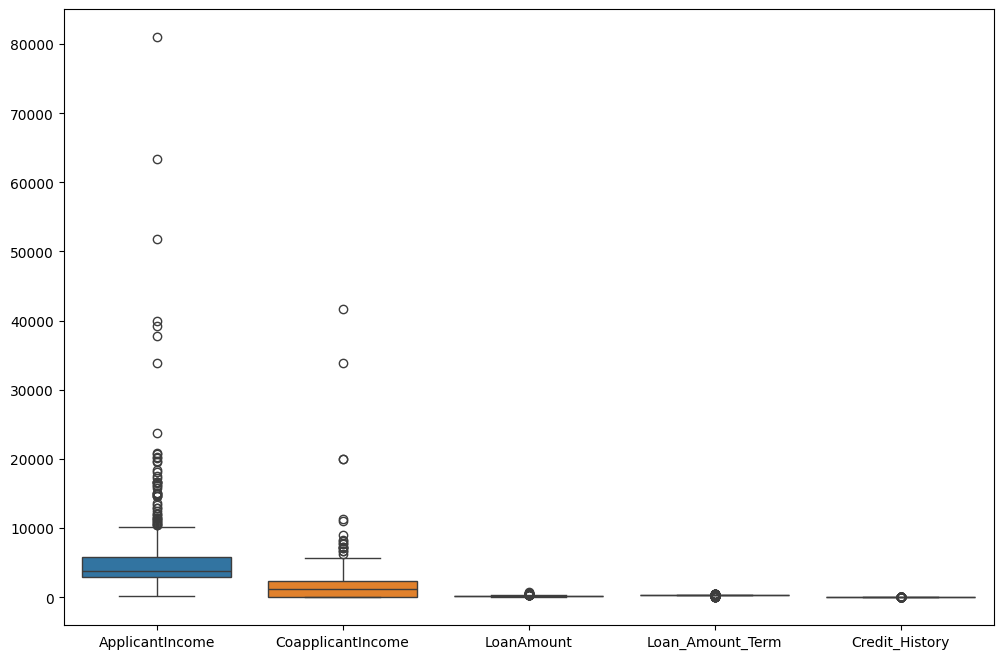

In [49]:
#check outliers
plt.figure(figsize=(12,8))
sns.boxplot(data = df)

In [50]:
## Fill the null values of numerical datatype
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

In [51]:
## Fill the null values of object datatype
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [52]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Jumlah Orang Yang Mengambil Pinjaman Berdasarkan Gender
Gender
Male      502
Female    112
Name: count, dtype: int64


<Axes: xlabel='Gender', ylabel='count'>

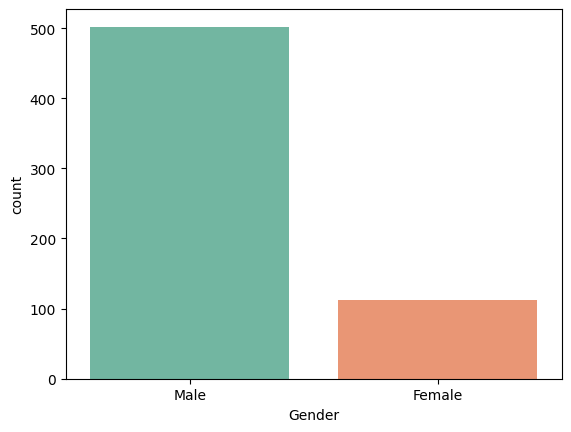

In [53]:
print('Jumlah Orang Yang Mengambil Pinjaman Berdasarkan Gender')
print(df['Gender'].value_counts())
sns.countplot(x='Gender', data = df, palette='Set2')

Jumlah Orang Yang Mengambil Pinjaman Berdasarkan Status Pernikahan
Married
Yes    401
No     213
Name: count, dtype: int64


<Axes: xlabel='Married', ylabel='count'>

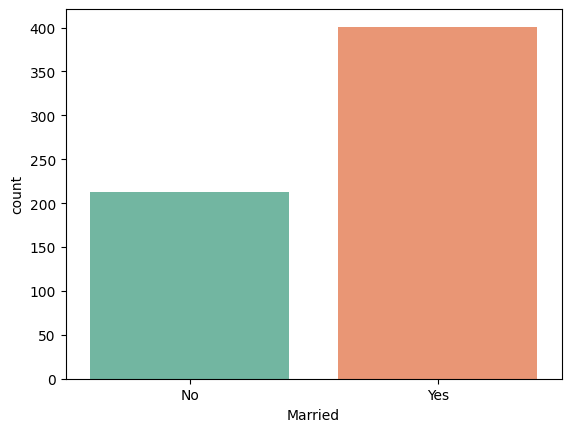

In [54]:
print('Jumlah Orang Yang Mengambil Pinjaman Berdasarkan Status Pernikahan')
print(df['Married'].value_counts())
sns.countplot(x='Married',data = df, palette='Set2')

Jumlah Orang Yang Mengambil Pinjaman Berdasarkan Pendidikan
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


<Axes: xlabel='Education', ylabel='count'>

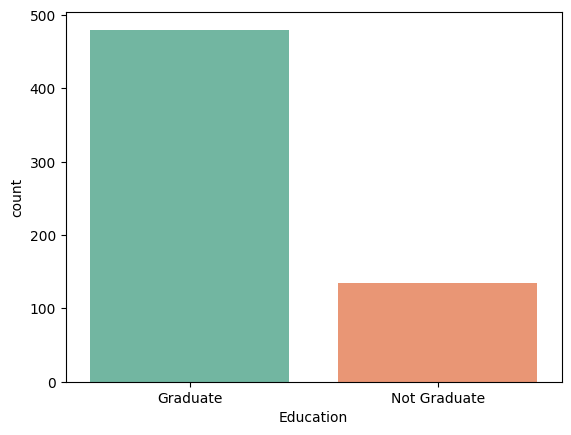

In [55]:
print('Jumlah Orang Yang Mengambil Pinjaman Berdasarkan Pendidikan')
print(df['Education'].value_counts())
sns.countplot(x='Education',data = df, palette='Set2')

<Axes: >

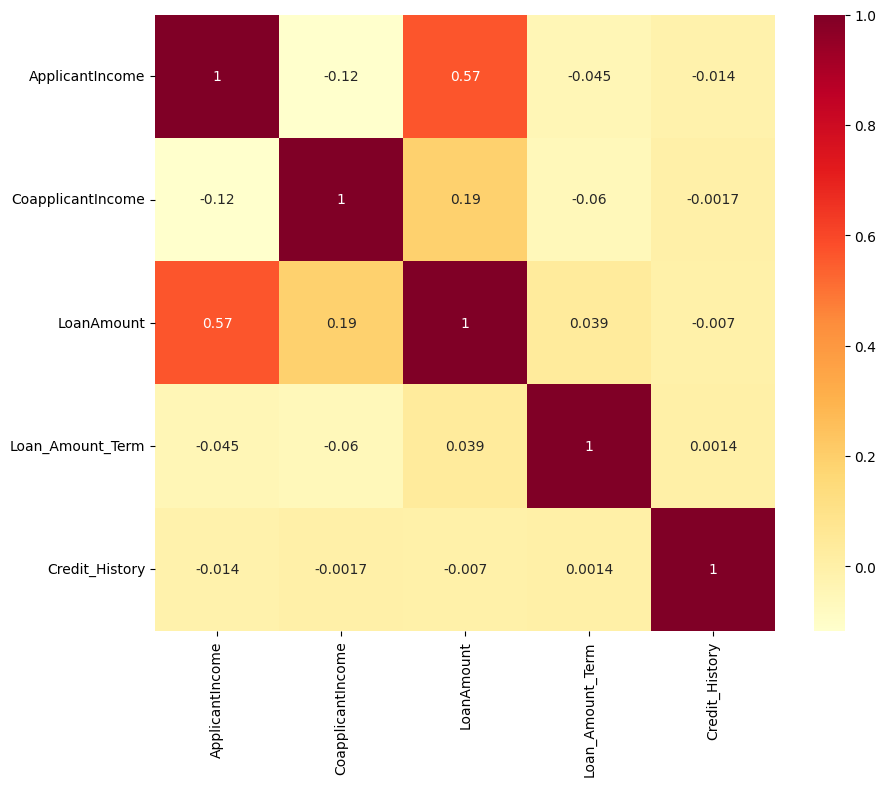

In [56]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot = True, cmap = 'YlOrRd')

In [57]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,9613.0
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y,3849.0
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N,5540.0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y,5532.0
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,23809.0


<Axes: xlabel='ApplicantIncomelog', ylabel='Density'>

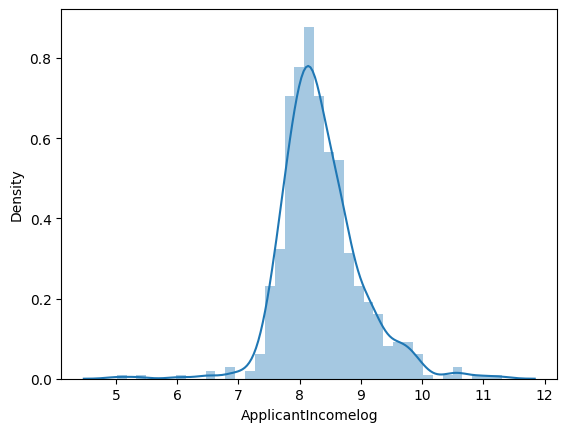

In [58]:
df['ApplicantIncomelog'] = np.log(df['ApplicantIncome'])
sns.distplot(df['ApplicantIncomelog'])

<Axes: xlabel='LoanAmountlog', ylabel='Density'>

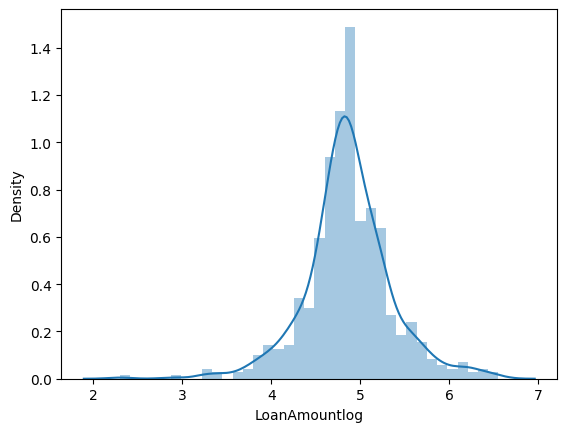

In [59]:
df['LoanAmountlog'] = np.log(df['LoanAmount'] + 1)
sns.distplot(df['LoanAmountlog'])

<Axes: xlabel='Loan_Amount_Term_log', ylabel='Density'>

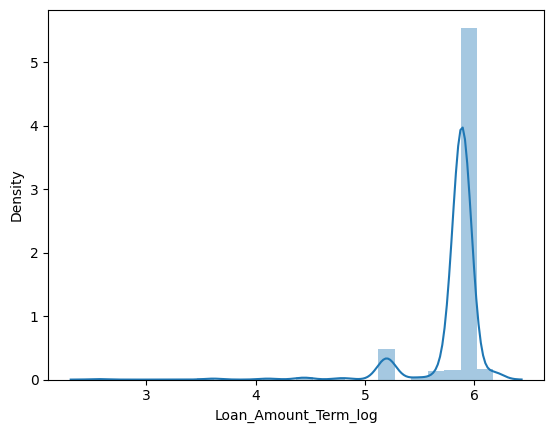

In [60]:
df['Loan_Amount_Term_log'] = np.log(df['Loan_Amount_Term'] + 1)
sns.distplot(df['Loan_Amount_Term_log'])

<Axes: xlabel='Total_Income_log', ylabel='Density'>

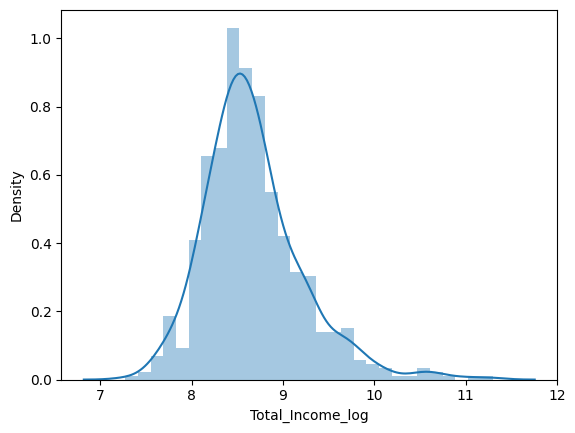

In [61]:
df['Total_Income_log'] = np.log(df['Total_Income']+1)
sns.distplot(df['Total_Income_log'])

In [62]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
Loan_ID,LP001002,LP001003,LP001005,LP001006,LP001008,LP001011,LP001013,LP001014,LP001018,LP001020
Gender,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
Married,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes
Dependents,0,1,0,0,0,2,0,3+,2,1
Education,Graduate,Graduate,Graduate,Not Graduate,Graduate,Graduate,Not Graduate,Graduate,Graduate,Graduate
Self_Employed,No,No,Yes,No,No,Yes,No,No,No,No
ApplicantIncome,5849,4583,3000,2583,6000,5417,2333,3036,4006,12841
CoapplicantIncome,0.0,1508.0,0.0,2358.0,0.0,4196.0,1516.0,2504.0,1526.0,10968.0
LoanAmount,128.0,128.0,66.0,120.0,141.0,267.0,95.0,158.0,168.0,349.0
Loan_Amount_Term,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0


In [63]:
cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Loan_ID']
df = df.drop(columns = cols, axis = 1)

In [64]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674026,4.859812,5.888878,8.674197
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430109,4.859812,5.888878,8.714732
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006368,4.204693,5.888878,8.006701
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.856707,4.795791,5.888878,8.505525
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699515,4.955827,5.888878,8.699681
5,Male,Yes,2,Graduate,Yes,1.0,Urban,Y,8.597297,5.590987,5.888878,9.170976
6,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.754910,4.564348,5.888878,8.255828
7,Male,Yes,3+,Graduate,No,0.0,Semiurban,N,8.018296,5.068904,5.888878,8.619930
8,Male,Yes,2,Graduate,No,1.0,Urban,Y,8.295549,5.129899,5.888878,8.618485
9,Male,Yes,1,Graduate,No,1.0,Semiurban,N,9.460398,5.857933,5.888878,10.077861


In [65]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
le = LabelEncoder()
for col in cols:
  df[col] = le.fit_transform(df[col])

In [66]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,0,0,0,0,1.0,2,1,8.674026,4.859812,5.888878,8.674197
1,1,1,1,0,0,1.0,0,0,8.430109,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,1,8.006368,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,1,7.856707,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,1,8.699515,4.955827,5.888878,8.699681
5,1,1,2,0,1,1.0,2,1,8.597297,5.590987,5.888878,9.170976
6,1,1,0,1,0,1.0,2,1,7.754910,4.564348,5.888878,8.255828
7,1,1,3,0,0,0.0,1,0,8.018296,5.068904,5.888878,8.619930
8,1,1,2,0,0,1.0,2,1,8.295549,5.129899,5.888878,8.618485
9,1,1,1,0,0,1.0,1,0,9.460398,5.857933,5.888878,10.077861


In [67]:
df.dtypes

,0
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
Credit_History,float64
Property_Area,int64
Loan_Status,int64
ApplicantIncomelog,float64
LoanAmountlog,float64


In [68]:
X = df.drop(columns = ['Loan_Status'],axis = 1)
y = df['Loan_Status']

In [69]:
X

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,0,0,0,0,1.0,2,8.674026,4.859812,5.888878,8.674197
1,1,1,1,0,0,1.0,0,8.430109,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,8.006368,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,7.856707,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,8.699515,4.955827,5.888878,8.699681
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,1.0,0,7.972466,4.276666,5.888878,7.972811
610,1,1,3,0,0,1.0,0,8.320205,3.713572,5.198497,8.320448
611,1,1,1,0,0,1.0,2,8.996157,5.537334,5.888878,9.025576
612,1,1,2,0,0,1.0,2,8.933664,5.236442,5.888878,8.933796


In [70]:
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [71]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

In [73]:
# Logistic Regression
Lr = LogisticRegression()
Lr.fit(X_train,y_train)
y_pred_Lr = Lr.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_Lr)
print('Logistic Regression Model Accuracy:',accuracy)

Logistic Regression Model Accuracy: 0.7727272727272727


In [74]:
score = cross_val_score(Lr,X,y,cv = 5)
print('Cross Validation Score:',score)

Cross Validation Score: [0.81300813 0.7804878  0.7804878  0.85365854 0.81967213]


In [75]:
np.mean(score)

np.float64(0.809462881514061)

In [76]:
# Decission Tree Classifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_dt)
print('Decission Tree Model Accuracy:',accuracy)

Decission Tree Model Accuracy: 0.7207792207792207


In [77]:
score = cross_val_score(dt,X,y,cv = 5)
print('Cross Validation Score:',score)

Cross Validation Score: [0.66666667 0.69105691 0.65853659 0.75609756 0.7295082 ]


In [78]:
np.mean(score)

np.float64(0.7003731840597094)

In [79]:
#Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_rf)
print('Random Forest Model Accuracy:', accuracy)

Random Forest Model Accuracy: 0.7792207792207793


In [80]:
#KNN
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_knn)
print('KNN Model Accuracy:', accuracy)

KNN Model Accuracy: 0.7142857142857143


In [81]:
from sklearn.metrics import classification_report

In [82]:
def generate_classification_report(model_name, y_test, y_pred):
  report = classification_report(y_test, y_pred)
  print(f'Classification Report for {model_name}:\n{report}')

generate_classification_report(Lr, y_test, y_pred_Lr)
generate_classification_report(rf, y_test, y_pred_rf)
generate_classification_report(dt, y_test, y_pred_dt)
generate_classification_report(knn, y_test, y_pred_knn)

Classification Report for LogisticRegression():
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154

Classification Report for RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.88      0.43      0.57        54
           1       0.76      0.97      0.85       100

    accuracy                           0.78       154
   macro avg       0.82      0.70      0.71       154
weighted avg       0.80      0.78      0.75       154

Classification Report for DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.61      0.56      0.58        54
           1       0.77      0.81      0.79       100

    accuracy                  